# 03: 研报策略样本外回测 (2015–2025)

使用与研报完全相同的策略参数（Call 期权 + 固定波动率锥阈值 + Delta 对冲），在全部样本外数据上进行回测。

In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
%matplotlib inline

sns.set_style('whitegrid')
from src.utils.visualize import setup_chinese_font
setup_chinese_font()

from src.data.preprocess import prepare_etf_daily, prepare_options_daily_with_greeks
from src.models.vol_cone import build_vol_cone, get_vol_threshold
from src.strategy.backtest import VolArbBacktest

SAVE_DIR = '../Data/processed/'
print('Imports OK')

## 1. 数据准备

加载 50ETF 日线（2010–2025）和 Call 期权数据（2015/2/9–2025/12/31）。

In [2]:
# 加载 ETF 日线
etf_full = prepare_etf_daily(start_date='2010-01-01', end_date='2025-12-31')
print(f'ETF 日线: {etf_full.shape[0]} 天, {etf_full.index.min().date()} ~ {etf_full.index.max().date()}')

# 加载 Call 期权（带 Greeks）
opts_c = prepare_options_daily_with_greeks(start_date='2015-02-09', end_date='2025-12-31', option_type='C')
print(f'Call 期权: {opts_c["code"].nunique()} 个合约, {len(opts_c):,} 条日线记录')

expiries = sorted(opts_c['EXPIRY_DATE'].unique())
print(f'到期月份: {len(expiries)} 个, {expiries[0].date()} ~ {expiries[-1].date()}')

ETF 日线: 3885 天, 2010-01-04 ~ 2025-12-31
Call 期权: 3400 个合约, 229,074 条日线记录
到期月份: 134 个, 2015-03-25 ~ 2026-06-24


## 2. 固定波动率锥阈值

沿用研报方法：使用 2010–2015 年历史数据构建波动率锥，取 20 日窗口 85% 分位作为固定开仓阈值。

波动率锥 (2010-2015):
        10     25     50     75     85     90
5     9.23  12.94  18.64  25.10  29.60  33.67
10   12.60  15.60  19.61  24.91  28.38  31.39
20   14.03  16.74  20.08  24.55  27.87  30.93
40   15.33  17.28  20.64  24.24  28.01  29.82
60   15.53  17.46  21.07  24.59  27.72  28.51
120  16.19  18.35  21.28  25.12  25.44  25.94

固定开仓阈值 (20日 85分位): 27.87%
研报阈值: 28.34%


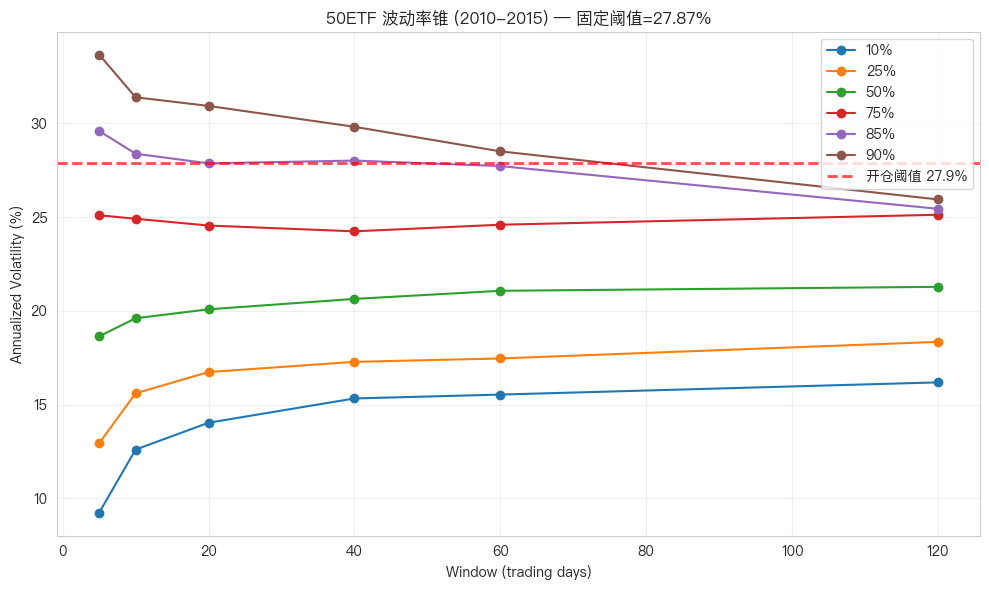

In [3]:
# 使用期权上市前的 5 年历史数据 (2010-2015) 构建波动率锥
etf_pre = prepare_etf_daily(start_date='2010-01-01', end_date='2015-02-08')
cone = build_vol_cone(etf_pre)
threshold = get_vol_threshold(cone, window=20, percentile=85)

print('波动率锥 (2010-2015):')
print((cone * 100).round(2).to_string())
print(f'\n固定开仓阈值 (20日 85分位): {threshold*100:.2f}%')
print(f'研报阈值: 28.34%')

# Visualize
from src.utils.visualize import plot_vol_cone
fig = plot_vol_cone(cone, title=f'50ETF 波动率锥 (2010-2015) — 固定阈值={threshold*100:.2f}%')
plt.axhline(y=threshold*100, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'开仓阈值 {threshold*100:.1f}%')
plt.legend()
plt.savefig(SAVE_DIR + '03_vol_cone_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 全样本回测：到期平仓

采用与研报完全一致的方法，在每个到期月内寻找 IV > 阈值的 Call 期权开仓，持有至到期。

In [4]:
def run_all_expiries(opts, etf, threshold, early_close=False, min_t=2):
    """Run backtest over all expiry months, return trades + equity curve."""
    all_trades = []
    all_daily_pnl = []
    n_expiries = len(opts['EXPIRY_DATE'].unique())
    for i, expiry in enumerate(sorted(opts['EXPIRY_DATE'].unique())):
        bt = VolArbBacktest(vol_threshold=threshold, r=0.04, commission_rate=0.0005,
                           min_t_days=min_t, option_type='call')
        result = bt.run(opts, etf, expiry_date=expiry, early_close=early_close)
        all_trades.extend(result.trades)
        if not result.equity_curve.empty:
            eq = result.equity_curve
            daily_delta = eq.diff().fillna(eq)
            all_daily_pnl.append(daily_delta)
        if (i+1) % 20 == 0:
            print(f'  Progress: {i+1}/{n_expiries} expiries done')
    # Combine equity
    if all_daily_pnl:
        combined = pd.concat(all_daily_pnl)
        equity = combined.groupby(combined.index).sum().cumsum()
    else:
        equity = pd.Series(dtype=float)
    return all_trades, equity

# Run hold-to-maturity backtest
print('Running hold-to-maturity backtest...')
trades_hold, equity_hold = run_all_expiries(opts_c, etf_full, threshold, early_close=False)
pnls_hold = [t.pnl for t in trades_hold]
wins_hold = [p for p in pnls_hold if p > 0]
losses_hold = [p for p in pnls_hold if p <= 0]

print(f'\n=== 到期平仓回测结果 ===')
print(f'总交易笔数: {len(trades_hold)}')
print(f'盈利: {len(wins_hold)}, 亏损: {len(losses_hold)}')
print(f'胜率: {len(wins_hold)/len(trades_hold)*100:.1f}%')
print(f'平均持仓: {np.mean([t.holding_days for t in trades_hold]):.1f} 天')
print(f'平均单笔 PnL: {np.mean(pnls_hold):.0f} 元')
print(f'总 PnL: {sum(pnls_hold):,.0f} 元')
print(f'最大回撤: {min(pnls_hold) if pnls_hold else 0:,.0f} 元')

Running hold-to-maturity backtest...
  Progress: 20/134 expiries done
  Progress: 40/134 expiries done
  Progress: 60/134 expiries done
  Progress: 80/134 expiries done
  Progress: 100/134 expiries done
  Progress: 120/134 expiries done

=== 到期平仓回测结果 ===
总交易笔数: 24042
盈利: 20069, 亏损: 3973
胜率: 83.5%
平均持仓: 55.7 天
平均单笔 PnL: 72 元
总 PnL: 1,737,284 元
最大回撤: -2,621 元


## 4. 全样本回测：提前平仓

到期日前若累计收益 >= 预期收益则提前平仓。

In [5]:
# Run early close backtest
print('Running early-close backtest...')
trades_early, equity_early = run_all_expiries(opts_c, etf_full, threshold, early_close=True)
pnls_early = [t.pnl for t in trades_early]
wins_early = [p for p in pnls_early if p > 0]
losses_early = [p for p in pnls_early if p <= 0]

print(f'\n=== 提前平仓回测结果 ===')
print(f'总交易笔数: {len(trades_early)}')
print(f'盈利: {len(wins_early)}, 亏损: {len(losses_early)}')
print(f'胜率: {len(wins_early)/len(trades_early)*100:.1f}%')
print(f'平均持仓: {np.mean([t.holding_days for t in trades_early]):.1f} 天')
print(f'平均单笔 PnL: {np.mean(pnls_early):.0f} 元')
print(f'总 PnL: {sum(pnls_early):,.0f} 元')
print(f'最大回撤: {min(pnls_early) if pnls_early else 0:,.0f} 元')

Running early-close backtest...
  Progress: 20/134 expiries done
  Progress: 40/134 expiries done
  Progress: 60/134 expiries done
  Progress: 80/134 expiries done
  Progress: 100/134 expiries done
  Progress: 120/134 expiries done

=== 提前平仓回测结果 ===
总交易笔数: 24042
盈利: 21349, 亏损: 2693
胜率: 88.8%
平均持仓: 40.2 天
平均单笔 PnL: 128 元
总 PnL: 3,086,438 元
最大回撤: -2,621 元


### 4.1 单笔交易收益分布

直方图展示每笔交易 PnL 的分布特征，对比到期平仓与提前平仓。

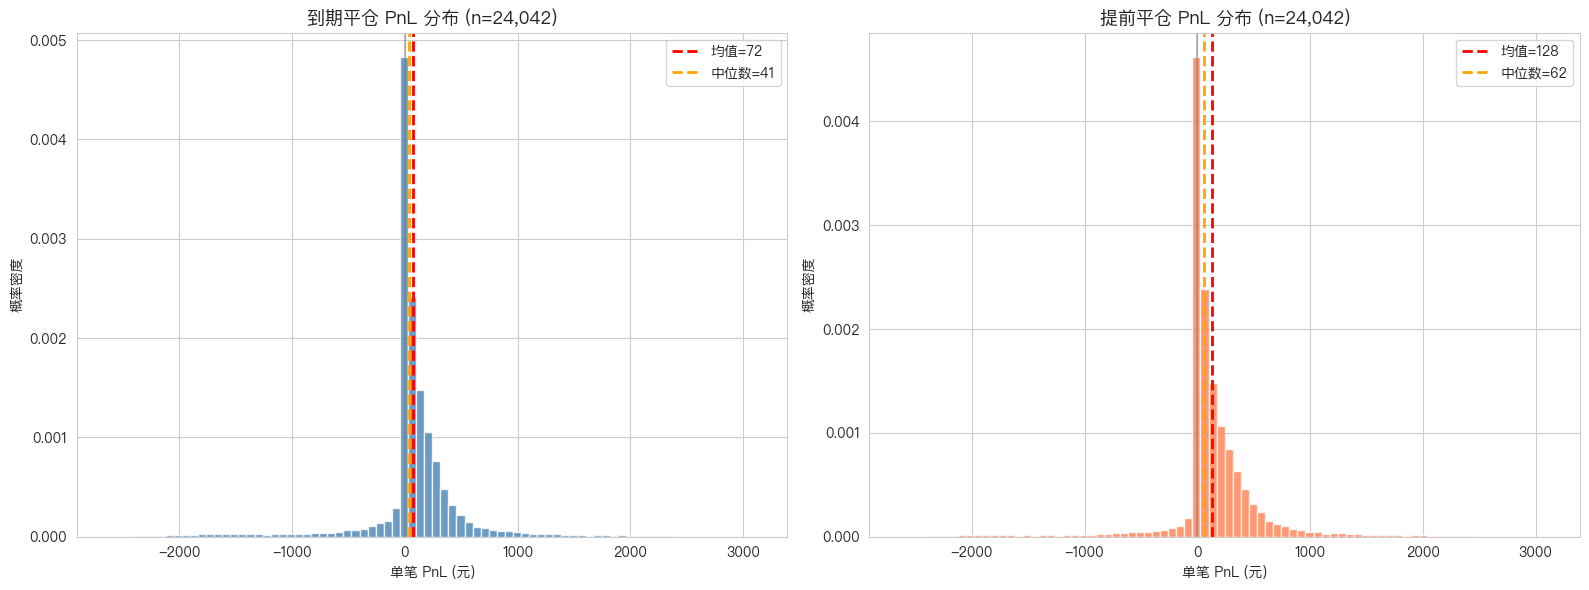

到期平仓 PnL: 均值=72, 中位数=41, 标准差=428
  偏度=-0.95, 峰度=10.51
提前平仓 PnL: 均值=128, 中位数=62, 标准差=403
  偏度=-0.45, 峰度=11.78


In [6]:
# 单笔交易 PnL 分布直方图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 到期平仓 PnL 分布
axes[0].hist(pnls_hold, bins=80, color='steelblue', alpha=0.8, edgecolor='white', density=True)
axes[0].axvline(x=np.mean(pnls_hold), color='red', linestyle='--', linewidth=2, label=f'均值={np.mean(pnls_hold):.0f}')
axes[0].axvline(x=np.median(pnls_hold), color='orange', linestyle='--', linewidth=2, label=f'中位数={np.median(pnls_hold):.0f}')
axes[0].axvline(x=0, color='gray', linestyle='-', alpha=0.5)
axes[0].set_title(f'到期平仓 PnL 分布 (n={len(pnls_hold):,})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('单笔 PnL (元)')
axes[0].set_ylabel('概率密度')
axes[0].legend()

# 提前平仓 PnL 分布
axes[1].hist(pnls_early, bins=80, color='coral', alpha=0.8, edgecolor='white', density=True)
axes[1].axvline(x=np.mean(pnls_early), color='red', linestyle='--', linewidth=2, label=f'均值={np.mean(pnls_early):.0f}')
axes[1].axvline(x=np.median(pnls_early), color='orange', linestyle='--', linewidth=2, label=f'中位数={np.median(pnls_early):.0f}')
axes[1].axvline(x=0, color='gray', linestyle='-', alpha=0.5)
axes[1].set_title(f'提前平仓 PnL 分布 (n={len(pnls_early):,})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('单笔 PnL (元)')
axes[1].set_ylabel('概率密度')
axes[1].legend()

plt.tight_layout()
plt.savefig(SAVE_DIR + '03_pnl_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'到期平仓 PnL: 均值={np.mean(pnls_hold):.0f}, 中位数={np.median(pnls_hold):.0f}, 标准差={np.std(pnls_hold):.0f}')
print(f'  偏度={pd.Series(pnls_hold).skew():.2f}, 峰度={pd.Series(pnls_hold).kurtosis():.2f}')
print(f'提前平仓 PnL: 均值={np.mean(pnls_early):.0f}, 中位数={np.median(pnls_early):.0f}, 标准差={np.std(pnls_early):.0f}')
print(f'  偏度={pd.Series(pnls_early).skew():.2f}, 峰度={pd.Series(pnls_early).kurtosis():.2f}')

## 5. 年度业绩分析

In [7]:
# 年度业绩汇总 (到期平仓)
def annual_summary(trades, equity):
    """Compute annual performance summary."""
    records = []
    for trade in trades:
        if trade.exit_date is not None:
            records.append({
                'year': trade.entry_date.year,
                'entry_date': trade.entry_date,
                'exit_date': trade.exit_date,
                'pnl': trade.pnl,
                'holding_days': trade.holding_days,
                'entry_iv': trade.entry_iv,
                'strike': trade.strike,
            })
    df = pd.DataFrame(records)
    if df.empty:
        return pd.DataFrame()

    annual = df.groupby('year').agg(
        num_trades=('pnl', 'count'),
        total_pnl=('pnl', 'sum'),
        avg_pnl=('pnl', 'mean'),
        avg_holding=('holding_days', 'mean'),
        avg_iv=('entry_iv', 'mean'),
    )
    # 单独计算胜率，避免 lambda 在 agg 中的兼容问题
    annual['num_wins'] = df.groupby('year')['pnl'].apply(lambda x: int((x > 0).sum()))
    annual['num_losses'] = df.groupby('year')['pnl'].apply(lambda x: int((x <= 0).sum()))
    annual['win_rate'] = (annual['num_wins'] / annual['num_trades'] * 100).astype(float)
    annual['cumulative_pnl'] = annual['total_pnl'].cumsum()
    return annual

annual_hold = annual_summary(trades_hold, equity_hold)
print('=== 年度业绩 (到期平仓) ===')
print(annual_hold.to_string())

annual_early = annual_summary(trades_early, equity_early)
print('\n=== 年度业绩 (提前平仓) ===')
print(annual_early.to_string())

# Save to CSV
annual_hold.to_csv(SAVE_DIR + '03_annual_performance_hold.csv', encoding='utf-8-sig')
annual_early.to_csv(SAVE_DIR + '03_annual_performance_early.csv', encoding='utf-8-sig')

=== 年度业绩 (到期平仓) ===
      num_trades      total_pnl     avg_pnl  avg_holding    avg_iv  num_wins  num_losses   win_rate  cumulative_pnl
year                                                                                                               
2015        8616  252000.336104   29.247950    86.615135  0.435312      6021        2595  69.881616    2.520003e+05
2016        1970  183366.935254   93.079663    49.870558  0.369576      1819         151  92.335025    4.353673e+05
2017         271   13634.426660   50.311537    16.265683  0.446912       264           7  97.416974    4.490017e+05
2018        2313  142828.755442   61.750435    33.453956  0.359422      2164         149  93.558150    5.918305e+05
2019        3475  561414.613536  161.558162    62.819281  0.349616      3269         206  94.071942    1.153245e+06
2020        2157  364351.863520  168.916024    40.920723  0.374643      1944         213  90.125174    1.517597e+06
2021        1239   32624.334063   26.331182    16.47

### 5.1 年度开仓信号统计

统计每年触发开仓条件 (IV > 阈值) 的交易次数。

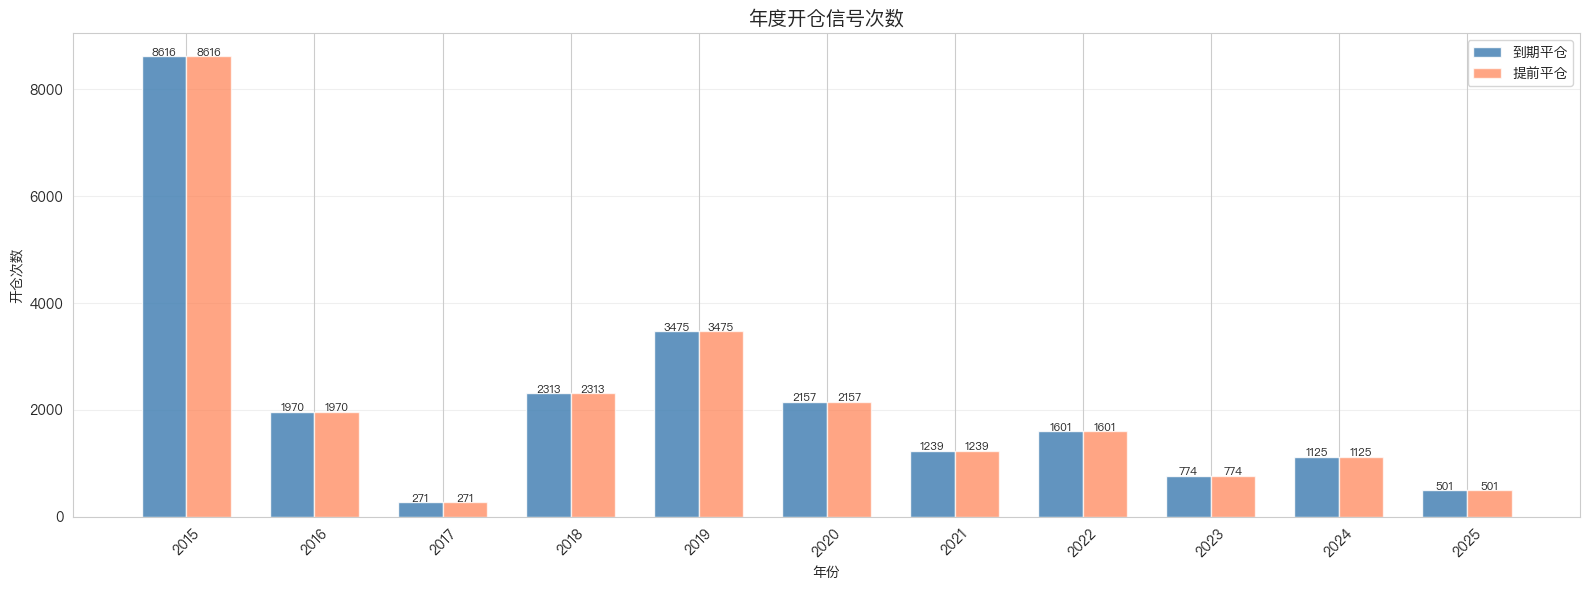

总开仓次数: 到期平仓=24,042, 提前平仓=24,042
年均开仓次数: 到期平仓=2186, 提前平仓=2186


In [8]:
# 年度开仓信号次数柱状图
# 统计每个 trades 的 entry_date 年份分布
entry_years_hold = pd.Series([t.entry_date.year for t in trades_hold])
entry_years_early = pd.Series([t.entry_date.year for t in trades_early])
signal_counts_hold = entry_years_hold.value_counts().sort_index()
signal_counts_early = entry_years_early.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(16, 6))
years_all = sorted(set(signal_counts_hold.index) | set(signal_counts_early.index))
x = np.arange(len(years_all))
width = 0.35

hold_vals = [signal_counts_hold.get(y, 0) for y in years_all]
early_vals = [signal_counts_early.get(y, 0) for y in years_all]

bars1 = ax.bar(x - width/2, hold_vals, width, color='steelblue', alpha=0.85, label='到期平仓')
bars2 = ax.bar(x + width/2, early_vals, width, color='coral', alpha=0.7, label='提前平仓')

# 标注数值
for bar, val in zip(bars1, hold_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10, str(val), ha='center', fontsize=8)
for bar, val in zip(bars2, early_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10, str(val), ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years_all], rotation=45)
ax.set_title('年度开仓信号次数', fontsize=14, fontweight='bold')
ax.set_xlabel('年份')
ax.set_ylabel('开仓次数')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(SAVE_DIR + '03_annual_signal_count.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'总开仓次数: 到期平仓={len(trades_hold):,}, 提前平仓={len(trades_early):,}')
print(f'年均开仓次数: 到期平仓={len(trades_hold)/len(years_all):.0f}, 提前平仓={len(trades_early)/len(years_all):.0f}')

## 6. 资金曲线

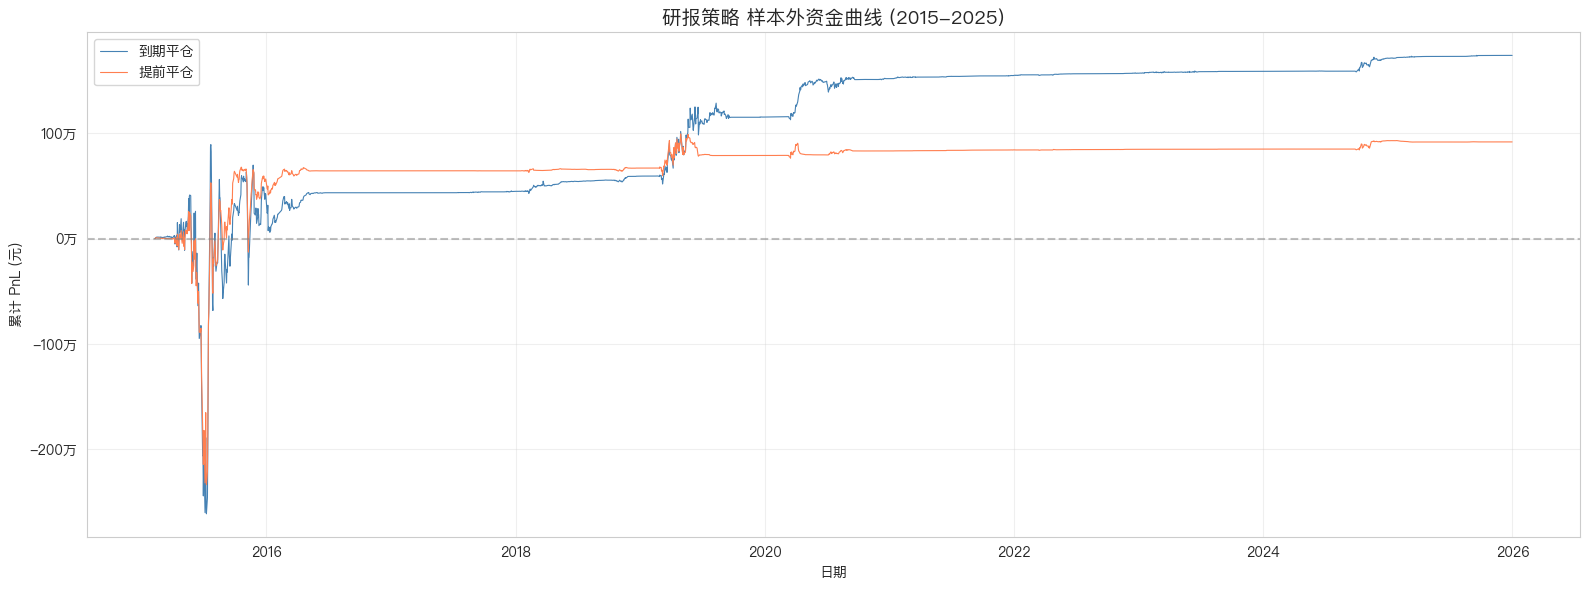

到期平仓: 最终 PnL=1,737,709, 最大回撤=-3,023,528, 年化收益=-1,157/年
提前平仓: 最终 PnL=917,088, 最大回撤=-2,589,590, 年化收益=-1,562/年


In [9]:
# 全周期资金曲线
fig, ax = plt.subplots(figsize=(16, 6))

if not equity_hold.empty:
    ax.plot(equity_hold.index, equity_hold.values, linewidth=0.8, color='steelblue', label='到期平仓')
if not equity_early.empty:
    ax.plot(equity_early.index, equity_early.values, linewidth=0.8, color='coral', label='提前平仓')

ax.set_title('研报策略 样本外资金曲线 (2015-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('日期')
ax.set_ylabel('累计 PnL (元)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
# Format y-axis in 万元
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/10000:.0f}万'))
plt.tight_layout()
plt.savefig(SAVE_DIR + '03_equity_curve_full.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key stats
for label, eq in [('到期平仓', equity_hold), ('提前平仓', equity_early)]:
    if not eq.empty:
        total_pnl = eq.iloc[-1]
        max_dd = (eq - eq.cummax()).min()
        print(f'{label}: 最终 PnL={total_pnl:,.0f}, 最大回撤={max_dd:,.0f}, '
              f'年化收益={total_pnl/eq.index.max().year-eq.index.min().year:,.0f}/年')

### 6.1 回撤曲线

累计收益曲线中，回撤 = 当前净值 - 历史最高净值。回撤反映策略的最大风险敞口。

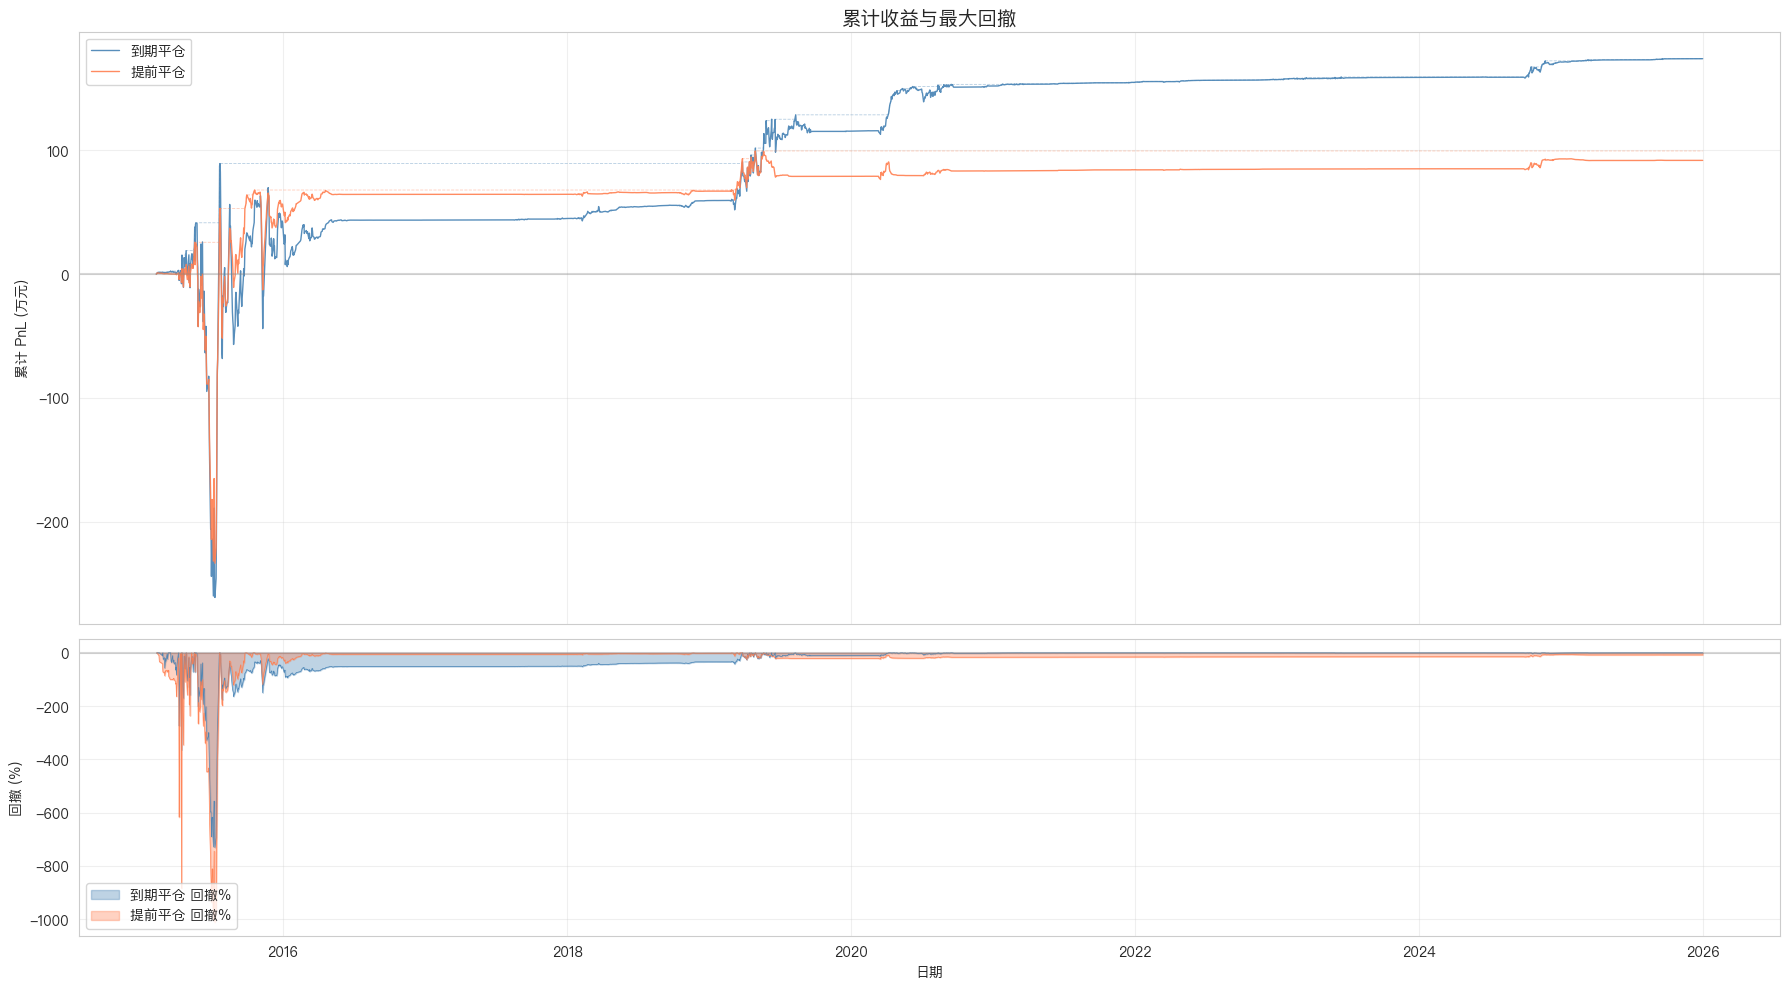

到期平仓:
  最大回撤: -3,023,528 元 (-730.9%)
  最大回撤日期: 2015-07-10
  平均回撤: -193,340 元
  回撤>5%的天数: 1208 / 2649 (45.6%)
提前平仓:
  最大回撤: -2,589,590 元 (-1011.3%)
  最大回撤日期: 2015-07-10
  平均回撤: -129,747 元
  回撤>5%的天数: 2307 / 2649 (87.1%)


In [10]:
# 回撤曲线
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

for label, eq, color in [('到期平仓', equity_hold, 'steelblue'), ('提前平仓', equity_early, 'coral')]:
    if eq.empty:
        continue
    cummax = eq.cummax()
    drawdown = eq - cummax
    dd_pct = (drawdown / cummax) * 100
    
    # 上图: 累计收益 + 历史最高
    axes[0].plot(eq.index, eq.values/10000, linewidth=1, color=color, alpha=0.9, label=label)
    axes[0].plot(eq.index, cummax.values/10000, linewidth=0.6, color=color, linestyle='--', alpha=0.4)
    
    # 下图: 回撤百分比
    axes[1].fill_between(eq.index, dd_pct.values, 0, alpha=0.35, color=color, label=f'{label} 回撤%')
    axes[1].plot(eq.index, dd_pct.values, linewidth=0.5, color=color, alpha=0.9)

axes[0].set_title('累计收益与最大回撤', fontsize=14, fontweight='bold')
axes[0].set_ylabel('累计 PnL (万元)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='gray', linestyle='-', alpha=0.3)

axes[1].set_xlabel('日期')
axes[1].set_ylabel('回撤 (%)')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='gray', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + '03_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

# 回撤统计
for label, eq in [('到期平仓', equity_hold), ('提前平仓', equity_early)]:
    if eq.empty:
        continue
    cummax = eq.cummax()
    dd = eq - cummax
    dd_pct = dd / cummax * 100
    max_dd_idx = dd_pct.idxmin()
    print(f'{label}:')
    print(f'  最大回撤: {dd.min():,.0f} 元 ({dd_pct.min():.1f}%)')
    print(f'  最大回撤日期: {max_dd_idx.date()}')
    print(f'  平均回撤: {dd.mean():,.0f} 元')
    print(f'  回撤>5%的天数: {(dd_pct < -5).sum()} / {len(dd_pct)} ({(dd_pct < -5).sum()/len(dd_pct)*100:.1f}%)')

## 7. 月度 PnL 热力图

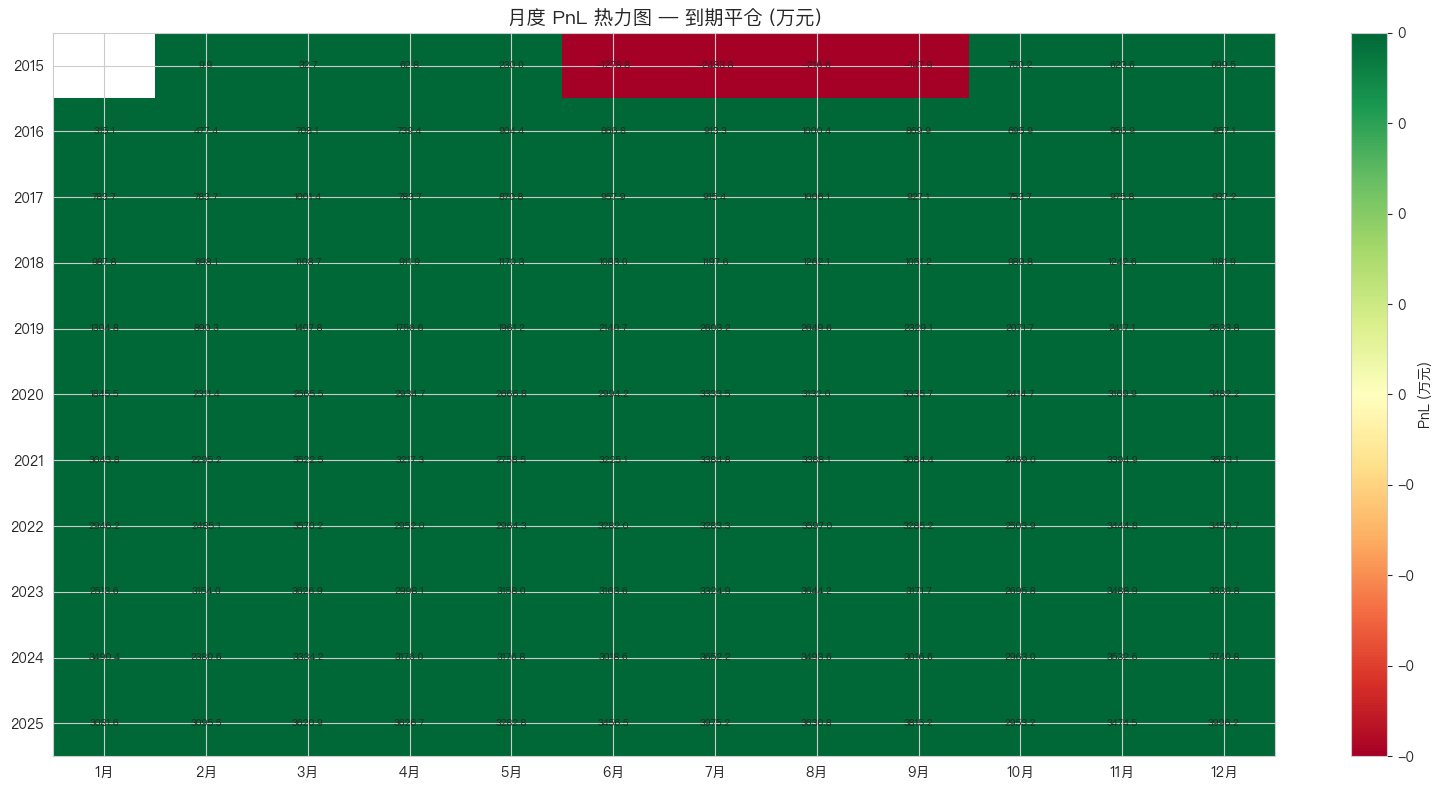

月度统计:
  盈利月: 127 / 131
  亏损月: 4 / 131
  平均月 PnL: 21,669,882
  最大月盈利: 39,961,951
  最大月亏损: -24,838,410


In [11]:
# 月度 PnL 热力图 (到期平仓)
if not equity_hold.empty:
    monthly = equity_hold.resample('ME').sum()
    monthly_df = pd.DataFrame({
        'Year': monthly.index.year,
        'Month': monthly.index.month,
        'PnL': monthly.values
    })
    pivot = monthly_df.pivot_table(index='Year', columns='Month', values='PnL', aggfunc='sum')
    
    fig, ax = plt.subplots(figsize=(16, 8))
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=-abs(pivot.values).max(), vmax=abs(pivot.values).max())
    ax.set_xticks(range(12))
    ax.set_xticklabels([f'{m}月' for m in range(1, 13)])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title('月度 PnL 热力图 — 到期平仓 (万元)', fontsize=14, fontweight='bold')
    # Add text labels
    for i in range(len(pivot.index)):
        for j in range(12):
            val = pivot.values[i, j]
            if not np.isnan(val) and abs(val) > 0:
                ax.text(j, i, f'{val/10000:.1f}', ha='center', va='center', fontsize=7)
    plt.colorbar(im, ax=ax, label='PnL (万元)', format=plt.FuncFormatter(lambda x, _: f'{x/10000:.0f}'))
    plt.tight_layout()
    plt.savefig(SAVE_DIR + '03_monthly_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'月度统计:')
    print(f'  盈利月: {(monthly > 0).sum()} / {len(monthly)}')
    print(f'  亏损月: {(monthly < 0).sum()} / {len(monthly)}')
    print(f'  平均月 PnL: {monthly.mean():,.0f}')
    print(f'  最大月盈利: {monthly.max():,.0f}')
    print(f'  最大月亏损: {monthly.min():,.0f}')

## 8. 年度 PnL 柱状图

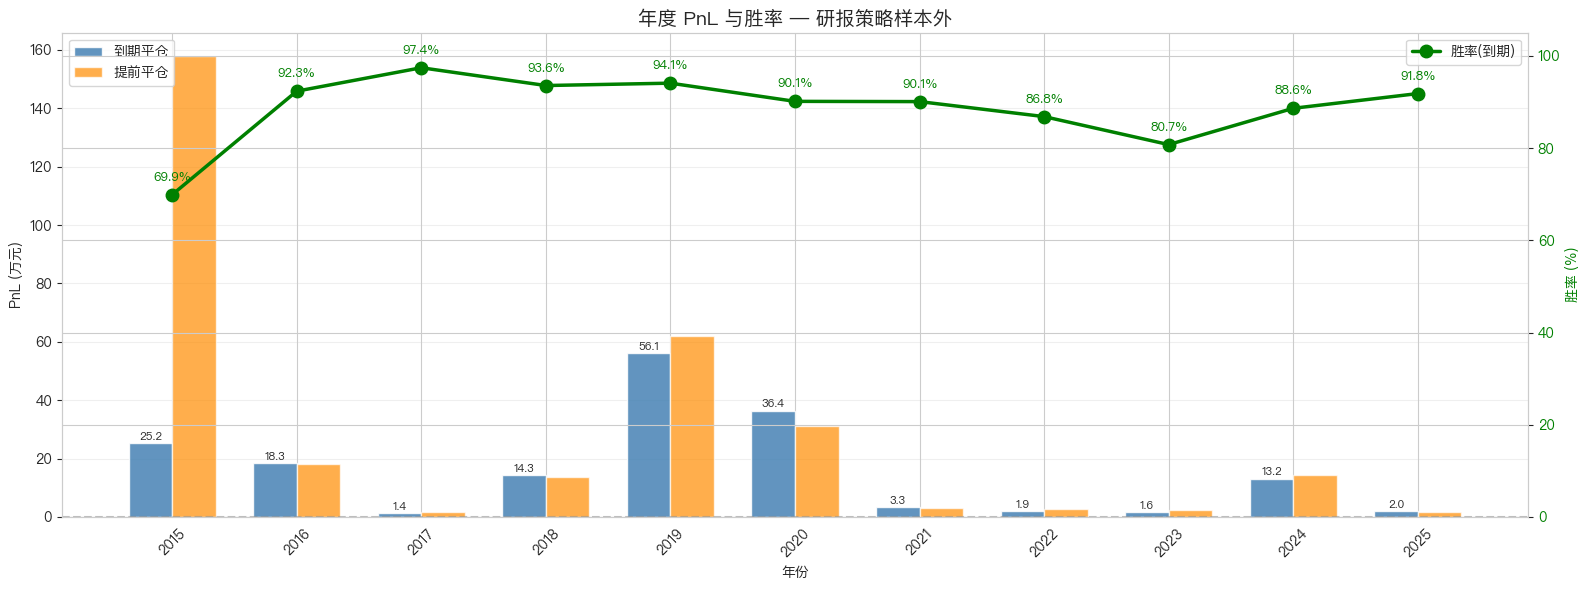

In [12]:
# 年度 PnL 柱状图 + 胜率折线 (双轴)
fig, ax1 = plt.subplots(figsize=(16, 6))

if not annual_hold.empty:
    years = annual_hold.index.astype(str)
    x = np.arange(len(years))
    width = 0.35

    colors_hold = ['coral' if v < 0 else 'steelblue' for v in annual_hold['total_pnl']]
    colors_early = ['red' if v < 0 else 'darkorange' for v in annual_early['total_pnl']]

    bars1 = ax1.bar(x - width/2, annual_hold['total_pnl']/10000, width, color=colors_hold, alpha=0.85, label='到期平仓')
    bars2 = ax1.bar(x + width/2, annual_early['total_pnl']/10000, width, color=colors_early, alpha=0.7, label='提前平仓')

    ax1.set_xticks(x)
    ax1.set_xticklabels(years, rotation=45)
    ax1.set_xlabel('年份')
    ax1.set_ylabel('PnL (万元)')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

    # PnL labels on bars
    for bar, val in zip(bars1, annual_hold['total_pnl']/10000):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (0.5 if val>0 else -2),
                f'{val:.1f}', ha='center', va='bottom' if val>0 else 'top', fontsize=8)

    # 胜率使用独立第二Y轴，放在后面确保 scale 正确
    ax2 = ax1.twinx()
    ax2.plot(x, annual_hold['win_rate'].values, 'o-', color='green', linewidth=2.5, markersize=9, label='胜率(到期)')
    ax2.set_ylabel('胜率 (%)', color='green')
    ax2.tick_params(axis='y', labelcolor='green')
    ax2.legend(loc='upper right')

    # 先自动缩放再设限，确保 ylim 生效
    ax2.relim()
    ax2.autoscale_view()
    ax2.set_ylim(0, 105)

    # 标注胜率数值
    for xi, wr in zip(x, annual_hold['win_rate'].values):
        ax2.annotate(f'{wr:.1f}%', (xi, wr), textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=9, color='green')

    ax1.set_title('年度 PnL 与胜率 — 研报策略样本外', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(SAVE_DIR + '03_yearly_pnl.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. 样本内 vs 样本外对比

将研报样本内结果 (2015/2/9-2015/3/25) 与全样本外结果进行对比。

In [13]:
# 样本内 vs 样本外对比
# (样本内结果来自 02 notebook)
in_sample = {
    '到期平仓': {'交易笔数': 16, '胜率': '93.8%', '总PnL': '2,001', '年化收益': '67.3%'},
    '提前平仓': {'交易笔数': 16, '胜率': '93.8%', '总PnL': '2,469', '年化收益': '83.1%'},
}

out_sample = {
    '到期平仓': {
        '交易笔数': f'{len(trades_hold)}',
        '胜率': f'{len(wins_hold)/len(trades_hold)*100:.1f}%' if trades_hold else 'N/A',
        '总PnL': f'{sum(pnls_hold):,.0f}' if pnls_hold else 'N/A',
        '年化收益': f'{sum(pnls_hold)/len(annual_hold):,.0f}/年' if len(pnls_hold) > 0 else 'N/A',
    },
    '提前平仓': {
        '交易笔数': f'{len(trades_early)}',
        '胜率': f'{len(wins_early)/len(trades_early)*100:.1f}%' if trades_early else 'N/A',
        '总PnL': f'{sum(pnls_early):,.0f}' if pnls_early else 'N/A',
        '年化收益': f'{sum(pnls_early)/len(annual_early):,.0f}/年' if len(pnls_early) > 0 else 'N/A',
    },
}

print('=== 样本内 vs 样本外 策略对比 ===')
print()
print(f'{"指标":<15} {"样本内(到期)":<15} {"样本外(到期)":<15} {"样本内(提前)":<15} {"样本外(提前)":<15}')
print('-' * 75)
metrics = ['交易笔数', '胜率', '总PnL', '年化收益']
for m in metrics:
    print(f'{m:<15} {in_sample["到期平仓"][m]:<15} {out_sample["到期平仓"][m]:<15} '
          f'{in_sample["提前平仓"][m]:<15} {out_sample["提前平仓"][m]:<15}')

print('\n说明:')
print('1. 样本内仅 1.5 个月 (2015/2/9-2015/3/25)，样本外约 10.8 年')
print('2. 样本内策略在特定市场环境下表现出色，样本外面临更多样的市场环境')
print('3. 固定阈值 (基于 2010-2015 数据) 在后续年份可能不再适用')

=== 样本内 vs 样本外 策略对比 ===

指标              样本内(到期)         样本外(到期)         样本内(提前)         样本外(提前)        
---------------------------------------------------------------------------
交易笔数            16              24042           16              24042          
胜率              93.8%           83.5%           93.8%           88.8%          
总PnL            2,001           1,737,284       2,469           3,086,438      
年化收益            67.3%           157,935/年       83.1%           280,585/年      

说明:
1. 样本内仅 1.5 个月 (2015/2/9-2015/3/25)，样本外约 10.8 年
2. 样本内策略在特定市场环境下表现出色，样本外面临更多样的市场环境
3. 固定阈值 (基于 2010-2015 数据) 在后续年份可能不再适用
